In [1]:
# ruff: noqa  # Expect this notebook to be of bad quality
%load_ext autoreload
%autoreload 2

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from pathlib import Path

from misophonia_dataset.interface import get_data_dir

from misophonia_anc._mlflow_stats import (
    get_mlflow_metric_history,
    auto_combine_mean_with_std,
    RUN_INDEX,
)

In [55]:
figs_dir = get_data_dir(dataset_name="report_figs")

In [47]:
get_mlflow_metric_history(("model-baseline-rep1", "model-baseline-rep2"), "train/epoch/loss")

,run_name,step,timestamp,train/epoch/loss,pretty_name
0,model-baseline-rep1,1,1777840596508,-7.233837,Baseline
57,model-baseline-rep1,58,1777918168681,-11.892211,Baseline
56,model-baseline-rep1,57,1777916790490,-11.835076,Baseline
55,model-baseline-rep1,56,1777915404901,-11.855409,Baseline
54,model-baseline-rep1,55,1777914038255,-11.797587,Baseline
...,...,...,...,...,...
102,model-baseline-rep2,23,1777691744175,-10.769598,Baseline (rep. 2)
101,model-baseline-rep2,22,1777690193847,-10.763733,Baseline (rep. 2)
99,model-baseline-rep2,20,1777687091499,-10.619029,Baseline (rep. 2)
118,model-baseline-rep2,39,1777716621374,-11.503267,Baseline (rep. 2)


In [4]:
auto_combine_mean_with_std(
    ("model-baseline-rep1", "model-baseline-rep2", "model-baseline-rep3"), "val/epoch/si_snr_improvement"
)

,run_name,step,timestamp,val/epoch/si_snr_improvement,val/epoch/si_snr_improvement_std
0,model-baseline-rep1,1,1777840596508,0.683738,1.308915
1,model-baseline-rep1,1,1777840596508,0.683738,1.548759
2,model-baseline-rep1,1,1777840596508,0.683738,1.317182
3,model-baseline-rep1,2,1777841952199,1.134515,1.681772
4,model-baseline-rep1,2,1777841952199,1.134515,1.648133
...,...,...,...,...,...
715,model-baseline-rep3,79,1777882691665,2.283842,5.121564
716,model-baseline-rep3,79,1777882691665,2.283842,4.886770
717,model-baseline-rep3,80,1777884041271,1.669377,5.009050
718,model-baseline-rep3,80,1777884041271,1.669377,4.734550


In [57]:
def pretty_count(x: float, pos: int | None = None) -> str:
    if abs(x) >= 1_000_000:
        return f"{x / 1_000_000:g}M"
    if abs(x) >= 1_000:
        return f"{x / 1_000:g}k"
    return f"{x:g}"


def plot_metric(
    data: pd.DataFrame,
    mean_col: str,
    *,
    split: str = "Validation",
    metric_name: str = "Metric",
    title: str | None = None,
    std_label: str = "Std Dev",
    std_col: str | None = None,
    save_to: Path | None = None,
) -> None:
    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))

    for run_name, group in data.groupby("run_name", observed=True):
        # make step = number of training samples seens (using run_index.train_size_per_epoch)
        # Get first pretty name of group
        pretty_name = group["pretty_name"].iloc[0]
        train_size = RUN_INDEX.get(run_name, {}).get("train_size", 10_000)
        train_size_per_epoch = RUN_INDEX.get(run_name, {}).get("train_size_per_epoch", train_size)
        group["train_samples_seen"] = group["step"] * train_size_per_epoch

        sns.lineplot(data=group, x="train_samples_seen", y=mean_col, label=pretty_name)

        if std_col is not None:
            plt.fill_between(
                group["train_samples_seen"],
                group[mean_col] - group[std_col],
                group[mean_col] + group[std_col],
                alpha=0.3,
                label=f"{std_label} ({pretty_name})",
            )

    if title is not None:
        plt.title(title)
    plt.xlabel("Training Samples Seen")
    plt.ylabel(metric_name)
    plt.gca().xaxis.set_major_formatter(FuncFormatter(pretty_count))
    plt.legend()

    if save_to is not None:
        save_to.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_to, bbox_inches="tight")

    plt.show()

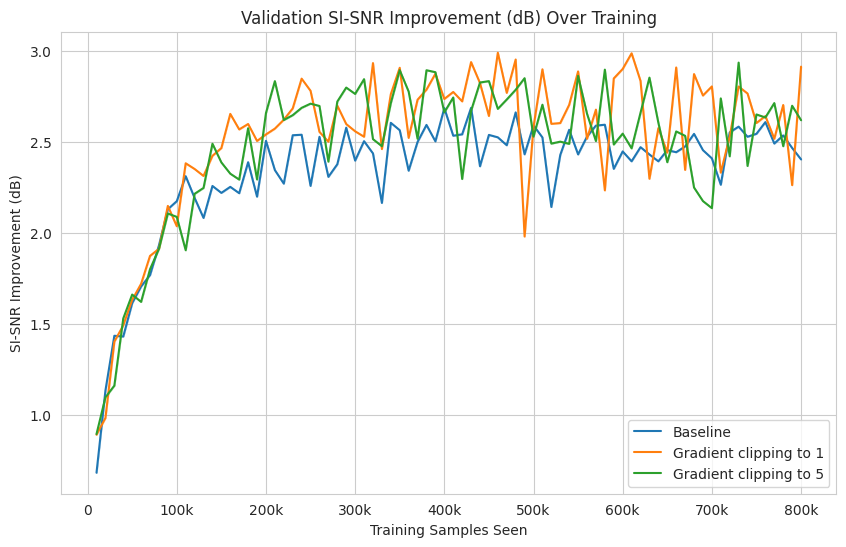

In [49]:
plot_metric(
    auto_combine_mean_with_std(
        (
            "model-baseline-rep1",
            "model-gradclip-1",
            "model-gradclip-5",
        ),
        "val/epoch/si_snr_improvement",
    ),
    "val/epoch/si_snr_improvement",
    metric_name="SI-SNR Improvement (dB)",
    # std_col="val/epoch/si_snr_improvement_std",
)

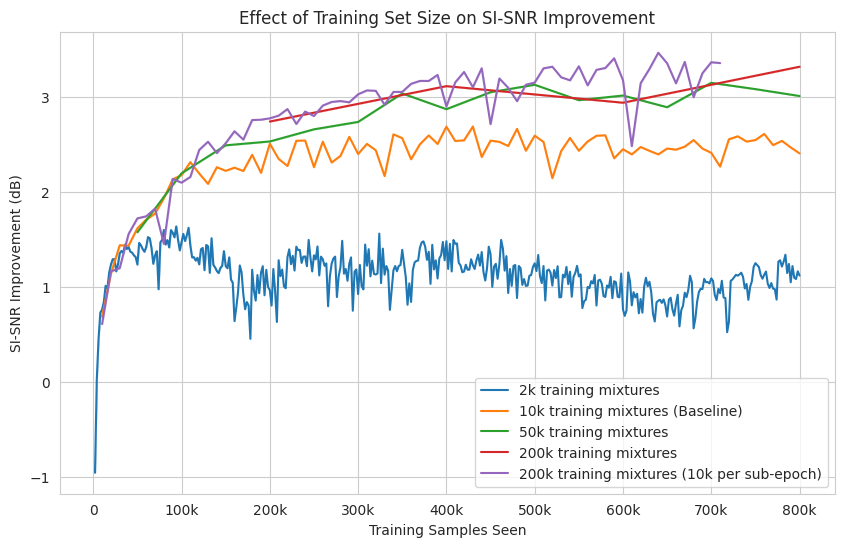

In [58]:
size_data = auto_combine_mean_with_std(
    (
        "model-size-2k",
        "model-baseline-rep1",
        "model-size-50k",
        "model-size-200k",
        "model-size-10k-of-200k",
    ),
    "val/epoch/si_snr_improvement",
)
# Remove step > 4 from model-size-200k (to keep it on the same scale)
size_data = size_data[~((size_data["run_name"] == "model-size-200k") & (size_data["step"] > 4))]

# Change pretty name of baseline to "Baseline (10k)"
size_data.loc[size_data["run_name"] == "model-baseline-rep1", "pretty_name"] = "10k training mixtures (Baseline)"

plot_metric(
    size_data,
    "val/epoch/si_snr_improvement",
    metric_name="SI-SNR Improvement (dB)",
    title="Effect of Training Set Size on SI-SNR Improvement",
    save_to=figs_dir / "training_size_effect.pdf",
    # std_col="val/epoch/si_snr_improvement_std",
)

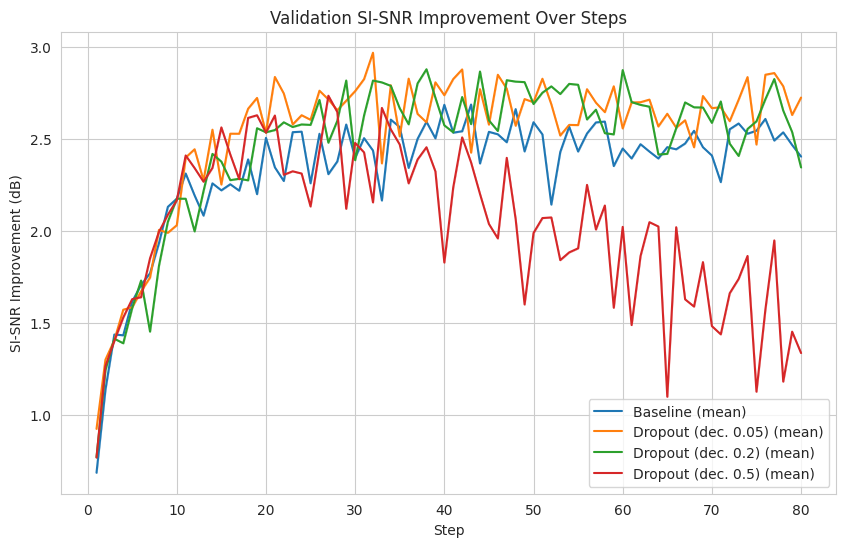

In [ ]:
plot_metric(
    auto_combine_mean_with_std(
        (
            "model-dropout-dec-0.05",
            "model-baseline-rep1",
            "model-dropout-dec-0.2",
            "model-dropout-dec-0.5",
        ),
        "val/epoch/si_snr_improvement",
    ),
    "val/epoch/si_snr_improvement",
    # std_col="val/epoch/si_snr_improvement_std",
)

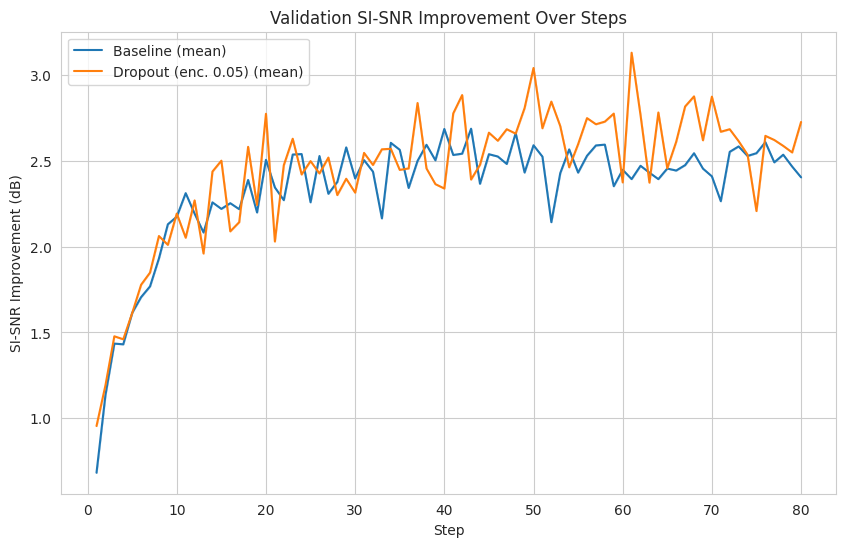

In [ ]:
plot_metric(
    auto_combine_mean_with_std(
        (
            "model-baseline-rep1",
            "model-dropout-enc-0.05",
        ),
        "val/epoch/si_snr_improvement",
    ),
    "val/epoch/si_snr_improvement",
    # std_col="val/epoch/si_snr_improvement_std",
)

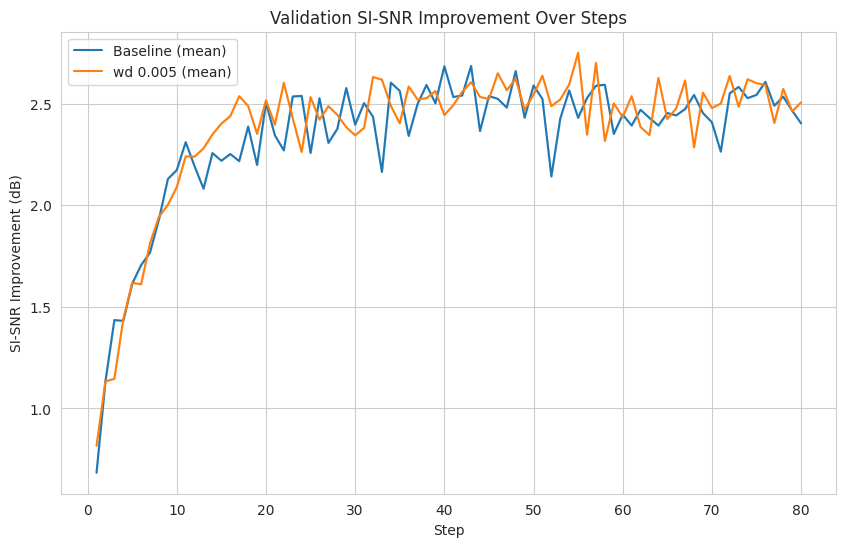

In [ ]:
plot_metric(
    auto_combine_mean_with_std(
        (
            "model-baseline-rep1",
            "model-lr-0.0005-wd-0.005",
        ),
        "val/epoch/si_snr_improvement",
    ),
    "val/epoch/si_snr_improvement",
    # std_col="val/epoch/si_snr_improvement_std",
)